# Libs

In [3]:
%matplotlib widget

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

import pydicom as dcm
import numpy as np
import pandas as pd

import cv2

# Paths

In [4]:
d_path = Path("../data/uncompressed/")

norma_name = "norma_anon"
pneumonia_name = "pneumonia_anon"
pneumothorax_name = "pneumotorax_anon"

norma_path = d_path / norma_name
pneumonia_path = d_path / pneumonia_name
pneumothorax_path = d_path / pneumothorax_name

norma_files = list(norma_path.glob("*"))
pneumonia_files = list(pneumonia_path.glob("*"))
pneumothorax_files = list(pneumothorax_path.glob("*"))
print(f"Normal files: {len(norma_files)}")
print(f"Pneumonia files: {len(pneumonia_files)}")
print(f"Pneumothorax files: {len(pneumothorax_files)}")

print(f"Normal size: {sum(f.stat().st_size for f in norma_files) / 1e6:.2f} MB")
print(f"Pneumonia size: {sum(f.stat().st_size for f in pneumonia_files) / 1e6:.2f} MB")
print(f"Pneumothorax size: {sum(f.stat().st_size for f in pneumothorax_files) / 1e6:.2f} MB")

Normal files: 451
Pneumonia files: 367
Pneumothorax files: 1
Normal size: 237.44 MB
Pneumonia size: 193.42 MB
Pneumothorax size: 249.85 MB


# DICOM sample

## Norma & Pneumonia

In [5]:
norma_data = np.array([dcm.dcmread(f).pixel_array for f in norma_files])
pneumonia_data = np.array([dcm.dcmread(f).pixel_array for f in pneumonia_files])
print(f"Normal shape: {norma_data.shape}")
print(f"Pneumonia shape: {pneumonia_data.shape}")

Normal shape: (451, 512, 512)
Pneumonia shape: (367, 512, 512)


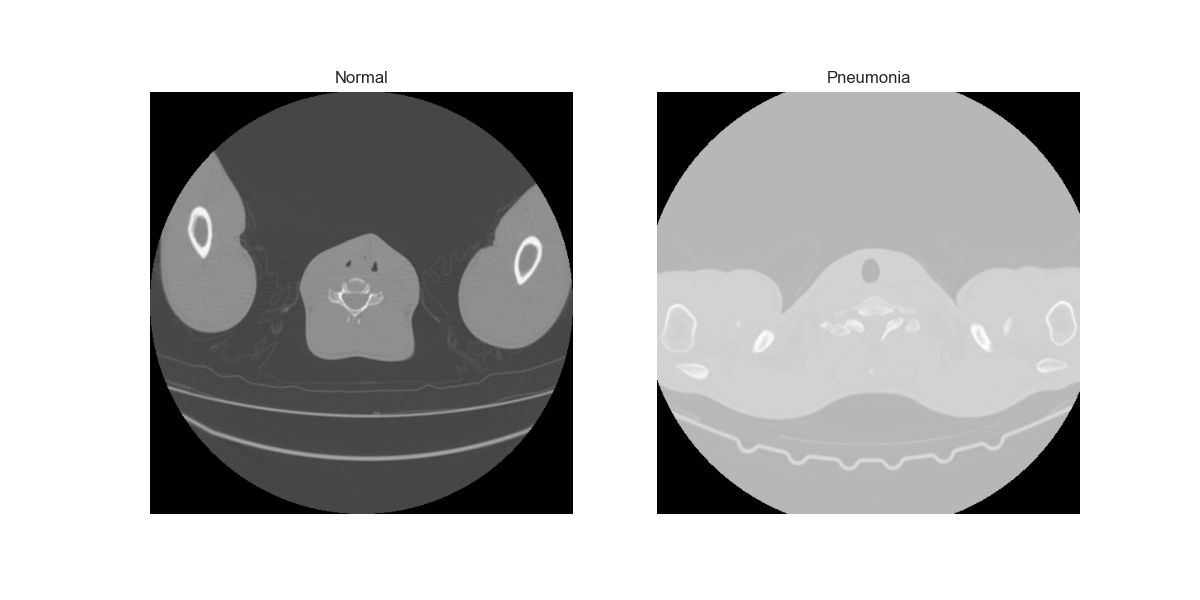

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

norma_sample = dcm.dcmread(norma_files[0])
pneumonia_sample = dcm.dcmread(pneumonia_files[0])

axes[0].imshow(norma_sample.pixel_array, cmap="gray")
axes[0].set_title("Normal")
axes[0].axis("off")

axes[1].imshow(pneumonia_sample.pixel_array, cmap="gray")
axes[1].set_title("Pneumonia")
axes[1].axis("off")

plt.show()

## Pneumothorax

In [7]:
pneumothorax_data = dcm.dcmread(pneumothorax_files[0]).pixel_array
pneumothorax_data.shape

(476, 512, 512)

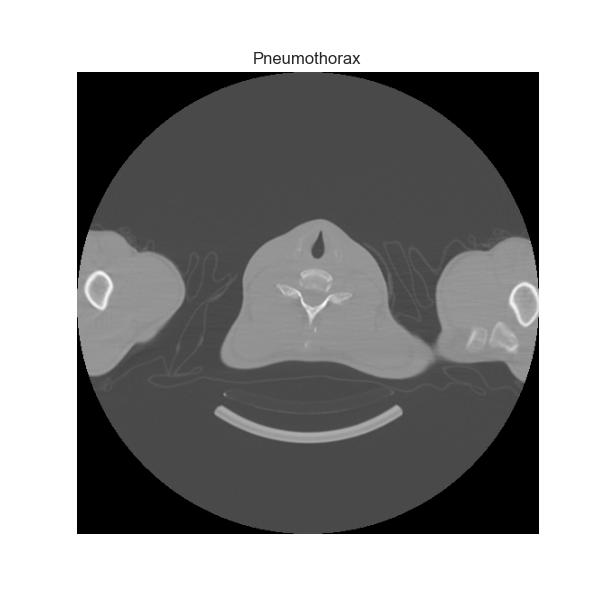

In [9]:
pneumothorax_sample = pneumothorax_data[0]
plt.figure(figsize=(6, 6))
plt.imshow(pneumothorax_sample, cmap="gray")
plt.title("Pneumothorax")
plt.axis("off")
plt.show()

# Shape distribution

In [10]:
norma_shapes = norma_data.shape
pneumonia_shapes = pneumonia_data.shape
pneumothorax_shapes = pneumothorax_data.shape

metadata = {
    "Condition": ["Normal", "Pneumonia", "Pneumothorax"],
    "Count": [norma_shapes[0], pneumonia_shapes[0], pneumothorax_shapes[0]],
    "Height": [norma_shapes[1], pneumonia_shapes[1], pneumothorax_shapes[1]],
    "Width": [norma_shapes[2], pneumonia_shapes[2], pneumothorax_shapes[2]],
}
metadata = pd.DataFrame(metadata)
metadata

,Condition,Count,Height,Width
0,Normal,451,512,512
1,Pneumonia,367,512,512
2,Pneumothorax,476,512,512


# Sliders

## Normal

IntSlider(value=0, continuous_update=False, description='Index:', max=450)

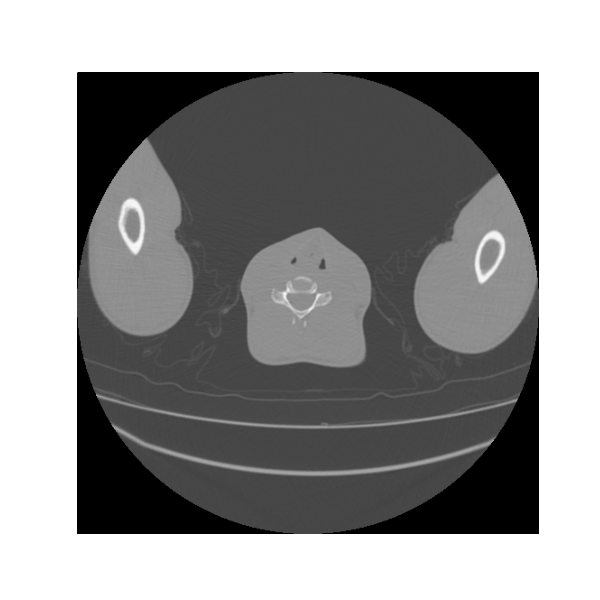

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

norma_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=norma_shapes[0] - 1,
    step=1,
    description="Index:",
    continuous_update=False,
)
im0 = norma_data[0]
img = ax.imshow(im0, cmap="gray")
ax.axis("off")

def update_image(change):
    idx = change["new"]
    im= norma_data[idx]
    img.set_data(im)
    fig.canvas.draw_idle()

norma_slider.observe(update_image, names="value")
display(norma_slider)
plt.show()

## Pneumonia

IntSlider(value=0, continuous_update=False, description='Index:', max=366)

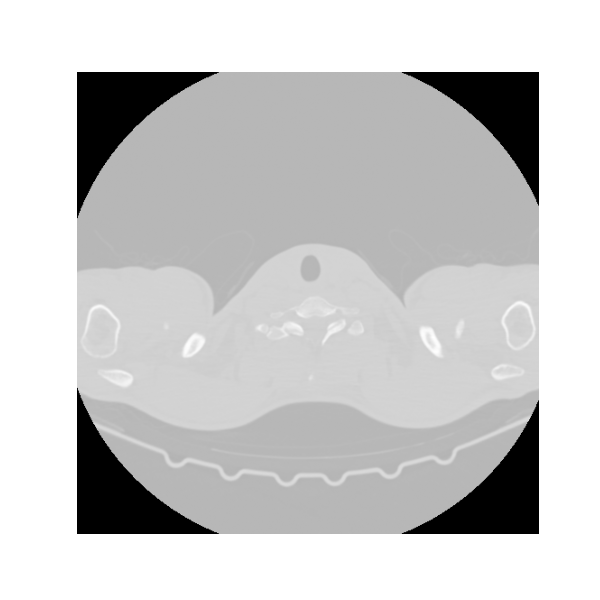

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
pneumonia_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=pneumonia_shapes[0] - 1,
    step=1,
    description="Index:",
    continuous_update=False,
)

im0 = pneumonia_data[0]
img = ax.imshow(im0, cmap="gray")
ax.axis("off")

def update_image(change):
    idx = change["new"]
    im= pneumonia_data[idx]
    img.set_data(im)
    fig.canvas.draw_idle()
pneumonia_slider.observe(update_image, names="value")
display(pneumonia_slider)
plt.show()

In [2]:
# TODO: если полистать снимки с разными диагнозами, то видно, что срезы выполнены с разных ракурсов, попробовать кластеризацию по ракурсу
# TODO: обязательно аугментация по гамме, rotate, контрасту, нормализация

## Pneumothorax

IntSlider(value=0, continuous_update=False, description='Index:', max=475)

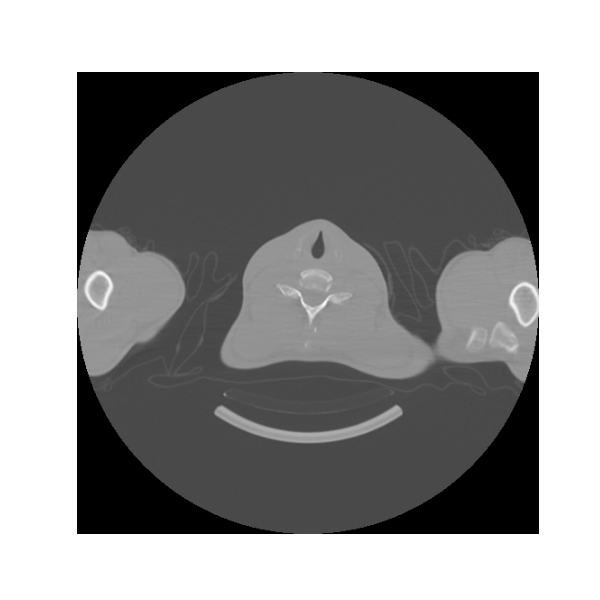

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

pneumothorax_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=pneumothorax_shapes[0] - 1,
    step=1,
    description="Index:",
    continuous_update=False,
)

im0 = pneumothorax_data[0]
img = ax.imshow(im0, cmap="gray")
ax.axis("off")

def update_image(change):
    idx = change["new"]
    im= pneumothorax_data[idx]
    img.set_data(im)
    fig.canvas.draw_idle()
pneumothorax_slider.observe(update_image, names="value")
display(pneumothorax_slider)
plt.show()

# Image Analysis

## Pixel Intensity Distribution

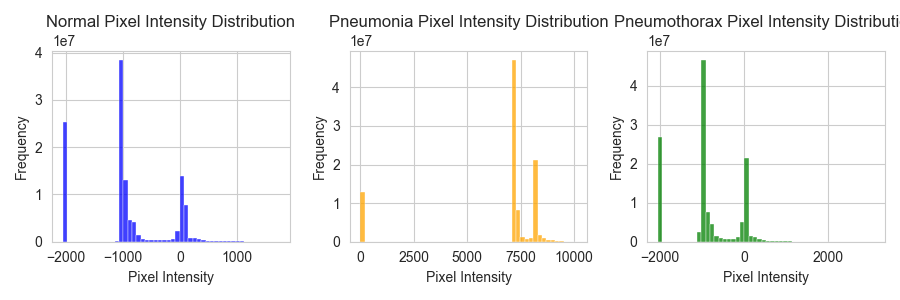

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
norma_dist = norma_data.flatten()
pneumonia_dist = pneumonia_data.flatten()
pneumothorax_dist = pneumothorax_data.flatten()

metadata["Mean Pixel Intensity"] = [
    np.mean(norma_dist),
    np.mean(pneumonia_dist),
    np.mean(pneumothorax_dist),
]

plt.figure(figsize=(8, 5))

sns.histplot(norma_dist, bins=50, color="blue", label="Normal", alpha=0.5)
sns.histplot(pneumonia_dist, bins=50, color="orange", label="Pneumonia", alpha=0.7)
sns.histplot(pneumothorax_dist, bins=50, color="green", label="Pneumothorax", alpha=0.5)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

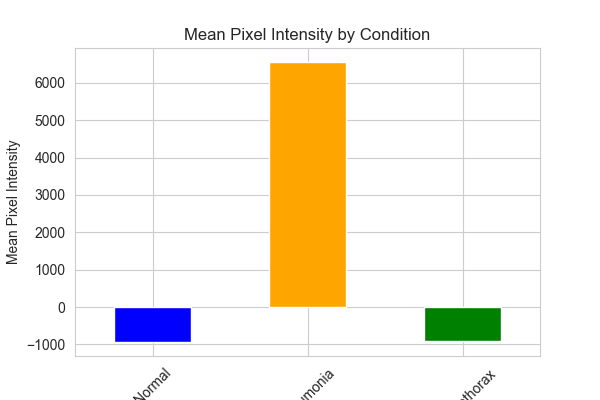

In [39]:
plt.figure(figsize=(6, 6))
metadata["Mean Pixel Intensity"].plot(kind="bar", color=["blue", "orange", "green"], figsize=(6, 4))
plt.title("Mean Pixel Intensity by Condition")
plt.xlabel("Condition")
plt.ylabel("Mean Pixel Intensity")
plt.xticks(ticks=range(len(metadata)), labels=metadata["Condition"], rotation=45)
plt.show()